# PCA through Singular Value Decomposition

In [ ]:
import numpy as np
# Defined 3 points in 2D-space:
X=np.array([[2, 1, 0],[4, 3, 0]])
# Calculate the covariance matrix:

# Calculate the SVD decomposition and new basis vectors:
[U,D,V]=np.linalg.svd(R)  # call SVD decomposition
u1=U[:,0] # new basis vectors
u2=U[:,1]

# Calculate the coordinates in new orthonormal basis:

# Calculate the approximation of the original from new basis
#print(Xi1[:,None]) # add second dimention to array and test it


# Check that you got the original


Original X:
[[2 1 0]
 [4 3 0]]
Centered X:
[[-1. -1.  0.]
 [ 1.  1.  0.]]
Covariance Matrix R:
[[2. 2. 0.]
 [2. 2. 0.]
 [0. 0. 0.]]
U (eigenvectors):
[[-0.70710678  0.         -0.70710678]
 [-0.70710678  0.          0.70710678]
 [ 0.          1.          0.        ]]
D (singular values):
[4. 0. 0.]
V (transpose of eigenvectors):
[[-0.70710678 -0.70710678 -0.        ]
 [ 0.          0.          1.        ]
 [-0.70710678  0.70710678  0.        ]]
New basis vector u1:
[-0.70710678 -0.70710678  0.        ]
New basis vector u2:
[0. 0. 1.]
Coordinates in new basis (Xi1, Xi2):
[ 1.41421356 -1.41421356]
[0. 0.]
Approximation of original X:
[[2. 1. 0.]
 [4. 3. 0.]]
Reconstruction using all principal components:
[[ 2.00000000e+00  1.00000000e+00 -1.01465364e-17]
 [ 4.00000000e+00  3.00000000e+00  1.01465364e-17]]


# PCA on Iris data

In [ ]:
# Load Iris dataset as in the last PC lab:
from sklearn.datasets import load_iris
iris=load_iris()
iris.feature_names
print(iris.feature_names)
print(iris.data[0:5,:])
print(iris.target[:])

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


<function matplotlib.pyplot.show(close=None, block=None)>

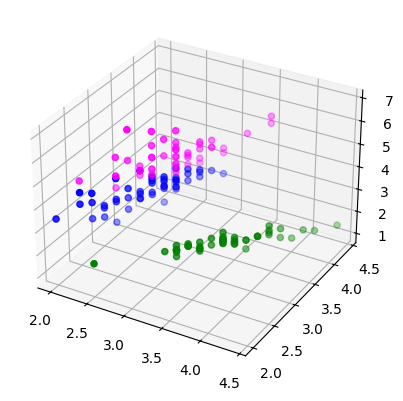

In [ ]:
# We have 4 dimensions of data, plot the first three colums in 3D
X=iris.data
y=iris.target
import matplotlib.pyplot as plt
axes1=plt.axes(projection='3d')
axes1.scatter3D(X[y==0,1],X[y==0,1],X[y==0,2],color='green')
axes1.scatter3D(X[y==1,1],X[y==1,1],X[y==1,2],color='blue')
axes1.scatter3D(X[y==2,1],X[y==2,1],X[y==2,2],color='magenta')
plt.show


[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


<function matplotlib.pyplot.show(close=None, block=None)>

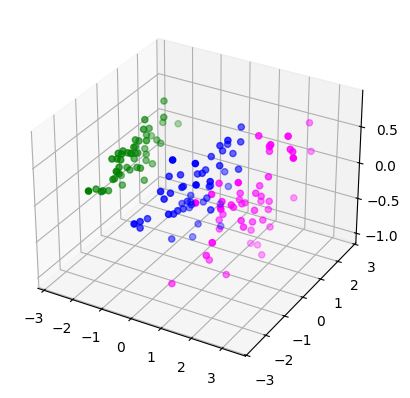

In [ ]:
# Pre-processing is an important step, you can try either StandardScaler (zero mean, unit variance of features)
# or MinMaxScaler (to interval from 0 to 1)
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
Xscaler = StandardScaler()
Xpp=Xscaler.fit_transform(X)

# define PCA object (three components), fit and transform the data
n_components=3
from sklearn import decomposition
pca = decomposition.PCA(n_components)
pca.fit(Xpp)
Xpca = pca.transform(Xpp)
print(pca.get_covariance())
# you can plot the transformed feature space in 3D:
axes2=plt.axes(projection='3d')
axes2.scatter3D(Xpca[y==0,0],Xpca[y==0,1],Xpca[y==0,2],color='green')
axes2.scatter3D(Xpca[y==1,0],Xpca[y==1,1],Xpca[y==1,2],color='blue')
axes2.scatter3D(Xpca[y==2,0],Xpca[y==2,1],Xpca[y==2,2],color='magenta')
plt.show


In [ ]:
# Compute pca.explained_variance_ and pca.explained_cariance_ratio_values
pca.explained_variance_

array([2.93808505, 0.9201649 , 0.14774182])

In [ ]:
pca.explained_variance_ratio_

array([0.72962445, 0.22850762, 0.03668922])

In [ ]:
# Plot the principal components in 2D, mark different targets in color




```
# Tiene formato de código
```

# KNN classifier

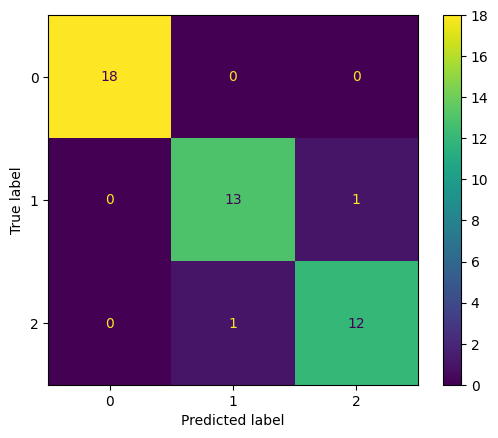

In [49]:
# Importaciones y carga de datos (normalmente en una celda anterior)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
y = iris.target

# Split X (original) into train and test, train KNN classifier on full 4-dimensional X
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
knn1 = KNeighborsClassifier(n_neighbors=3)
knn1.fit(X_train, y_train)
Ypred = knn1.predict(X_test)

confusion_matrix(y_test, Ypred)
ConfusionMatrixDisplay.from_predictions(y_test, Ypred)
plt.show()

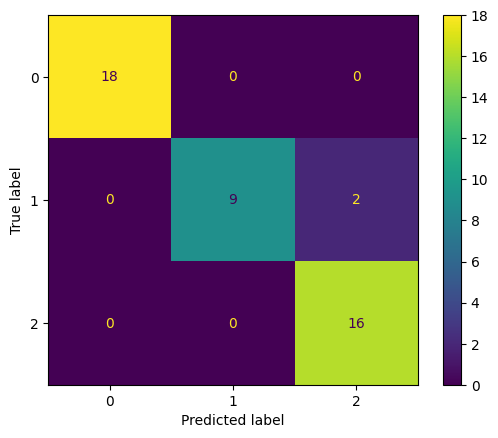

In [55]:
# Now do the same (data set split, KNN, confusion matrix), but for PCA-transformed data (1st two princ
# Compare the results with full dataset

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(Xpca[:,0:3], y, test_size=0.3)
knn2 = KNeighborsClassifier(n_neighbors=3)
knn2.fit(X_train_pca, y_train_pca)
Ypred_pca = knn2.predict(X_test_pca)

confusion_matrix(y_test_pca,Ypred_pca)
ConfusionMatrixDisplay.from_predictions(y_test_pca, Ypred_pca)
plt.show()

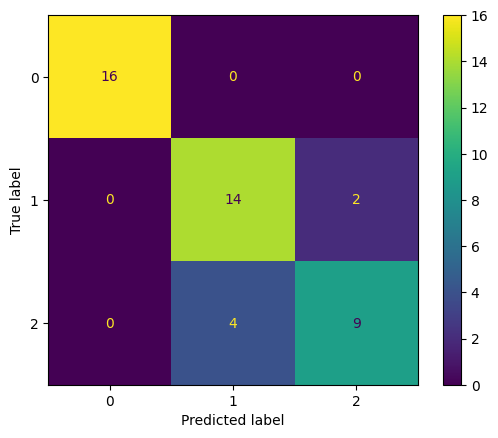

In [59]:
# Now do the same, but use only 2-dimensional data of original X (first two columns)
X2D = X[:, :2]

X_train_2D, X_test_2D, y_train_2D, y_test_2D = train_test_split(X2D, y, test_size=0.3)
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train_2D, y_train_2D)
Ypred_2D = knn3.predict(X_test_2D)

ConfusionMatrixDisplay.from_predictions(y_test_2D, Ypred_2D)
plt.show()